In [25]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from sklearn.metrics import mutual_info_score
from sklearn.neighbors import NearestNeighbors
from scipy.stats import bartlett, chi2
from scipy.spatial.distance import pdist, squareform
from statsmodels.tsa.stattools import acf, pacf

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
sensor = pd.read_csv("/content/drive/MyDrive/Complex Systems/sensor_hrv_filtered.csv")
sensor.head()

,deviceId,ts_start,ts_end,missingness_score,HR,ibi,acc_x_avg,acc_y_avg,acc_z_avg,grv_x_avg,...,calories,light_avg,sdnn,sdsd,rmssd,pnn20,pnn50,lf,hf,lf/hf
0,ab60,1617262425031,1617262724833,0.295448,84.592816,728.534374,0.284765,-0.593973,9.195984,-0.094203,...,0.000000,841.324415,89.363225,78.033038,98.417649,0.746269,0.391791,1818.065625,1252.992443,1.450979
1,ab60,1616736817151,1616737116986,0.239085,78.589565,781.896913,3.050179,-1.239353,5.790543,-0.211973,...,0.085083,486.485050,100.804974,73.468687,106.602933,0.803704,0.540741,1918.499169,2784.393293,0.689019
2,ab60,1616736517083,1616736816952,0.100773,75.620524,812.183910,2.153267,-3.546833,8.499866,-0.628970,...,NaN,779.033113,89.073518,48.675496,74.504896,0.809816,0.484663,1292.696555,1034.550027,1.249525
3,ab60,1616736217077,1616736516883,0.268178,85.813165,769.754943,2.898409,-3.401356,4.606113,-0.249247,...,1.375000,389.408638,102.371770,48.631219,70.615187,0.719178,0.400685,1561.785747,812.118619,1.923101
4,ab60,1616734416800,1616734716672,0.043466,76.944500,775.190053,-0.050221,-6.576164,5.377019,0.715893,...,0.000000,276.345515,84.045665,42.104491,66.973170,0.736111,0.450000,3460.217895,1886.157661,1.834533


In [9]:
sensor = sensor.sort_values(["deviceId", "ts_start"]) #organazing by deviceld and timestamp
hrv_vars = ["sdnn", "sdsd", "rmssd", "pnn20", "pnn50", "lf", "hf", "lf/hf"]
results = []

In [30]:
#Bartels rank test for randomness
def bartels_rank_test(series, alpha=0.02):
 series = pd.Series(series).dropna()
 n = len(series)
 if n < 3:
  return {"n": n, "rvn": np.nan, "z": np.nan, "p_value": np.nan, "decision": "not enough data"}
 #rank data
 ranks = series.rank(method="average")
 #compute RVN
 diff = np.diff(ranks)
 num = np.sum(diff**2)
 mean_rank = (n + 1) / 2
 denom = np.sum((ranks - mean_rank)**2)
 rvn = num / denom
 #expected value and variance under randomness
 expected_rvn = 2.0
 var_rvn =(4 * (n - 2) * (5 * n**2 - 2 * n - 9)) / (5 * n * (n + 1) * (n - 1)**2)
 z = (rvn - expected_rvn) / np.sqrt(var_rvn)
 #p-value
 p_value = 2 * (1 - 0.5 *(1 + math.erf(abs(z) / math.sqrt(2))))

 decision = "reject_H0" if p_value < alpha else "fail_to_reject_H0"

 return {
     "n": n,
     "rvn": rvn,
     "z": z,
     "p_value": p_value,
     "decision": decision
 }

In [35]:
metrics = ["HR", "sdnn", "rmssd"]
results = []

for device_id, grp in sensor.groupby("deviceId"):
  grp_sorted = grp.sort_values("ts_start")

  for metric_name in metrics:
    series = grp_sorted[metric_name].dropna().values
    #Bartels
    bart = bartels_rank_test(series)

    #ACF
    try:
      acf_vals = acf(series, nlags=5, fft=False)
      acf1 = acf_vals[1]
      acf5 = acf_vals[5]
    except:
      acf1 = np.nan
      acf5 = np.nan
    #PACF
    try:
      pacf_vals = pacf(series, nlags=5)
      pacf1 = pacf_vals[1]
    except:
      pacf1 = np.nan
    #Saving the results
    results.append({
        "deviceID": device_id,
        "metric": metric_name,
        "n": bart["n"],
        "rvn": bart["rvn"],
        "z": bart["z"],
        "p_value": bart["p_value"],
        "decision": bart["decision"],
        "acf1": acf1,
        "acf5": acf5,
        "pacf1": pacf1
    })
#final dataframe
df_fin = pd.DataFrame(results)

In [36]:
df_fin.head()

,deviceID,metric,n,rvn,z,p_value,decision,acf1,acf5,pacf1
0,ab60,HR,1103,0.461552,-25.563277,0.00000,reject_H0,0.769594,0.363404,0.770293
1,ab60,sdnn,1103,1.210187,-13.123756,0.00000,reject_H0,0.310349,0.228556,0.310630
2,ab60,rmssd,1103,1.381071,-10.284296,0.00000,reject_H0,0.180524,0.204949,0.180688
3,am77,HR,285,0.748103,-10.593365,0.00000,reject_H0,0.626048,0.162032,0.628252
4,am77,sdnn,285,1.593898,-3.436379,0.00059,reject_H0,0.121826,0.017118,0.122255


In [37]:
survey = pd.read_csv("/content/drive/MyDrive/Complex Systems/survey.csv")

In [44]:
df_wide = df_fin.pivot(
    index="deviceID",
    columns="metric",
    values=["rvn", "acf1", "acf5", "pacf1", "p_value"]
)

In [45]:
df_wide.columns = [f"{stat}_{metric}" for stat, metric in df_wide.columns]
df_wide = df_wide.reset_index()

In [50]:
df_wide = df_wide.rename(columns={"deviceID": "deviceId"})
df_merged = survey.merge(df_wide, on="deviceId", how="inner")

In [52]:
df_merged.head()

,deviceId,sex,age,marriage,occupation,smartwatch,regular,exercise,coffee,smoking,...,acf1_sdnn,acf5_HR,acf5_rmssd,acf5_sdnn,pacf1_HR,pacf1_rmssd,pacf1_sdnn,p_value_HR,p_value_rmssd,p_value_sdnn
0,pm96,1,36,1,3,1,3,5,4,1,...,0.302783,0.533456,0.076048,0.070901,0.849135,0.313699,0.303035,0.0,0.000000e+00,0.000000e+00
1,vc10,2,31,1,3,2,2,5,2,1,...,0.297829,0.342268,0.025479,0.047646,0.743290,0.298661,0.298790,0.0,1.221535e-07,7.485398e-09
2,pg18,2,38,1,3,1,3,3,3,1,...,0.444191,0.167002,-0.060748,0.007167,0.669564,0.442056,0.445789,0.0,1.987077e-12,8.881784e-16
3,nd56,2,40,3,2,1,4,4,5,1,...,0.414317,0.629391,0.376534,0.219457,0.857475,0.616207,0.414464,0.0,0.000000e+00,0.000000e+00
4,vs14,2,28,1,2,2,4,2,2,1,...,0.479414,0.275166,0.092353,0.129394,0.722608,0.455953,0.480015,0.0,0.000000e+00,0.000000e+00


In [53]:
corr = df_merged.corr(numeric_only=True)
corr["ISI_F"].sort_values(ascending=False)

,ISI_F
ISI_F,1.000000
ISI_2,0.840857
PHQ9_F,0.778371
PHQ9_1,0.764397
ISI_1,0.760933
PHQ9_2,0.649478
GAD7_F,0.614739
regular,0.590098
GAD7_1,0.568375
GAD7_2,0.459827


In [72]:
corr["GAD7_F"].sort_values(ascending=False)

,GAD7_F
GAD7_F,1.000000
PHQ9_F,0.810184
PHQ9_1,0.715199
GAD7_2,0.702224
PHQ9_2,0.694862
GAD7_1,0.693839
ISI_F,0.614739
ISI_2,0.549696
regular,0.526018
ISI_1,0.511262


In [73]:
corr["PHQ9_F"].sort_values(ascending=False)

,PHQ9_F
PHQ9_F,1.000000
PHQ9_1,0.823663
GAD7_F,0.810184
ISI_F,0.778371
PHQ9_2,0.770047
ISI_2,0.696826
GAD7_1,0.629226
GAD7_2,0.624983
ISI_1,0.617914
regular,0.614669


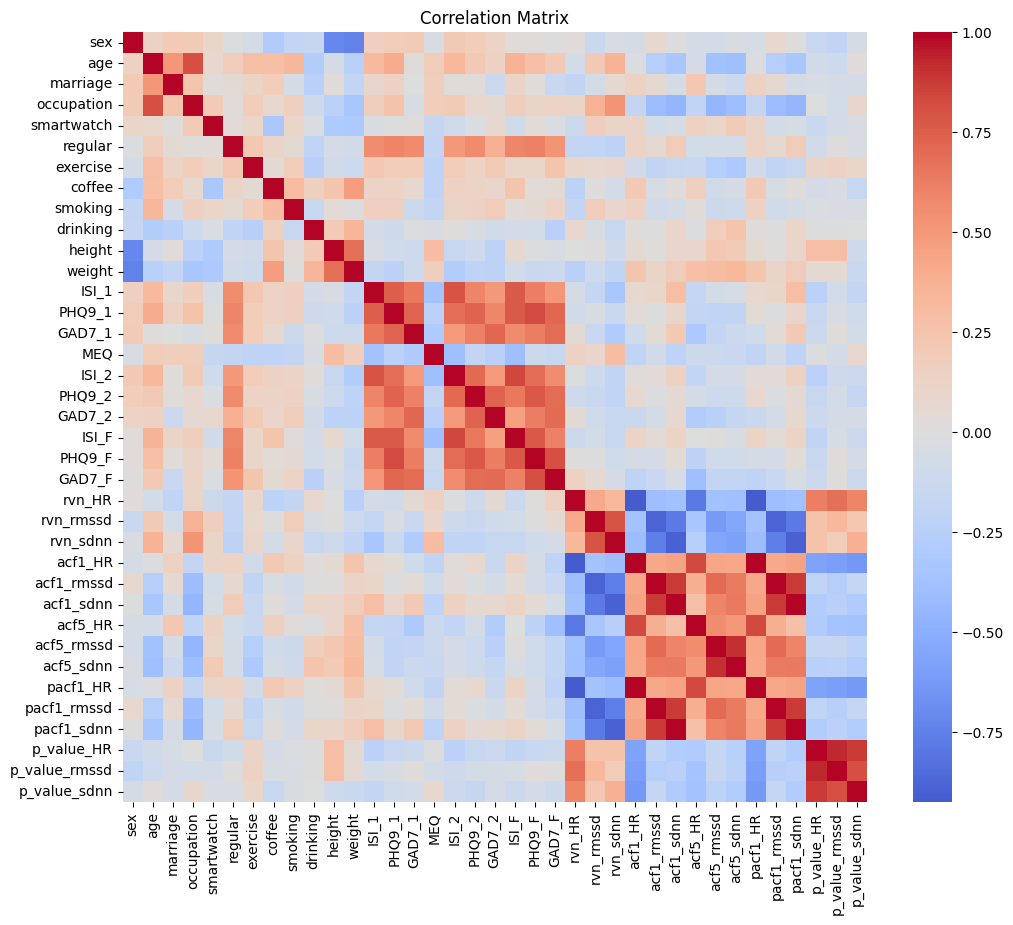

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()


In [56]:
import statsmodels.api as sm

X = df_merged[[
    "rvn_HR", "rvn_sdnn", "rvn_rmssd",
    "acf1_HR", "acf1_sdnn", "acf1_rmssd",
    "pacf1_HR", "pacf1_rmssd", "pacf1_sdnn"
]]

y = df_merged["ISI_F"]

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  ISI_F   R-squared:                       0.176
Model:                            OLS   Adj. R-squared:                 -0.014
Method:                 Least Squares   F-statistic:                    0.9276
Date:                Thu, 16 Apr 2026   Prob (F-statistic):              0.512
Time:                        17:05:38   Log-Likelihood:                -139.34
No. Observations:                  49   AIC:                             298.7
Df Residuals:                      39   BIC:                             317.6
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          16.7015     21.674      0.771      

In [57]:
df_merged["insomnia_binary"] = (df_merged["ISI_F"] >= 15).astype(int)

In [58]:
logit_model = sm.Logit(df_merged["insomnia_binary"], sm.add_constant(X)).fit()
print(logit_model.summary())

         Current function value: 0.132555
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:        insomnia_binary   No. Observations:                   49
Model:                          Logit   Df Residuals:                       39
Method:                           MLE   Df Model:                            9
Date:                Thu, 16 Apr 2026   Pseudo R-squ.:                  0.5312
Time:                        17:06:15   Log-Likelihood:                -6.4952
converged:                      False   LL-Null:                       -13.854
Covariance Type:            nonrobust   LLR p-value:                   0.09898
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const         143.6698    117.664      1.221      0.222     -86.947     374.286
rvn_HR          7.3993     29.515      0.251      0.802     -5

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [59]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=False)

,0
rvn_sdnn,0.301274
rvn_rmssd,0.123528
acf1_rmssd,0.110193
pacf1_rmssd,0.108343
pacf1_sdnn,0.087384
acf1_sdnn,0.078470
rvn_HR,0.075204
pacf1_HR,0.060710
acf1_HR,0.054893
const,0.000000


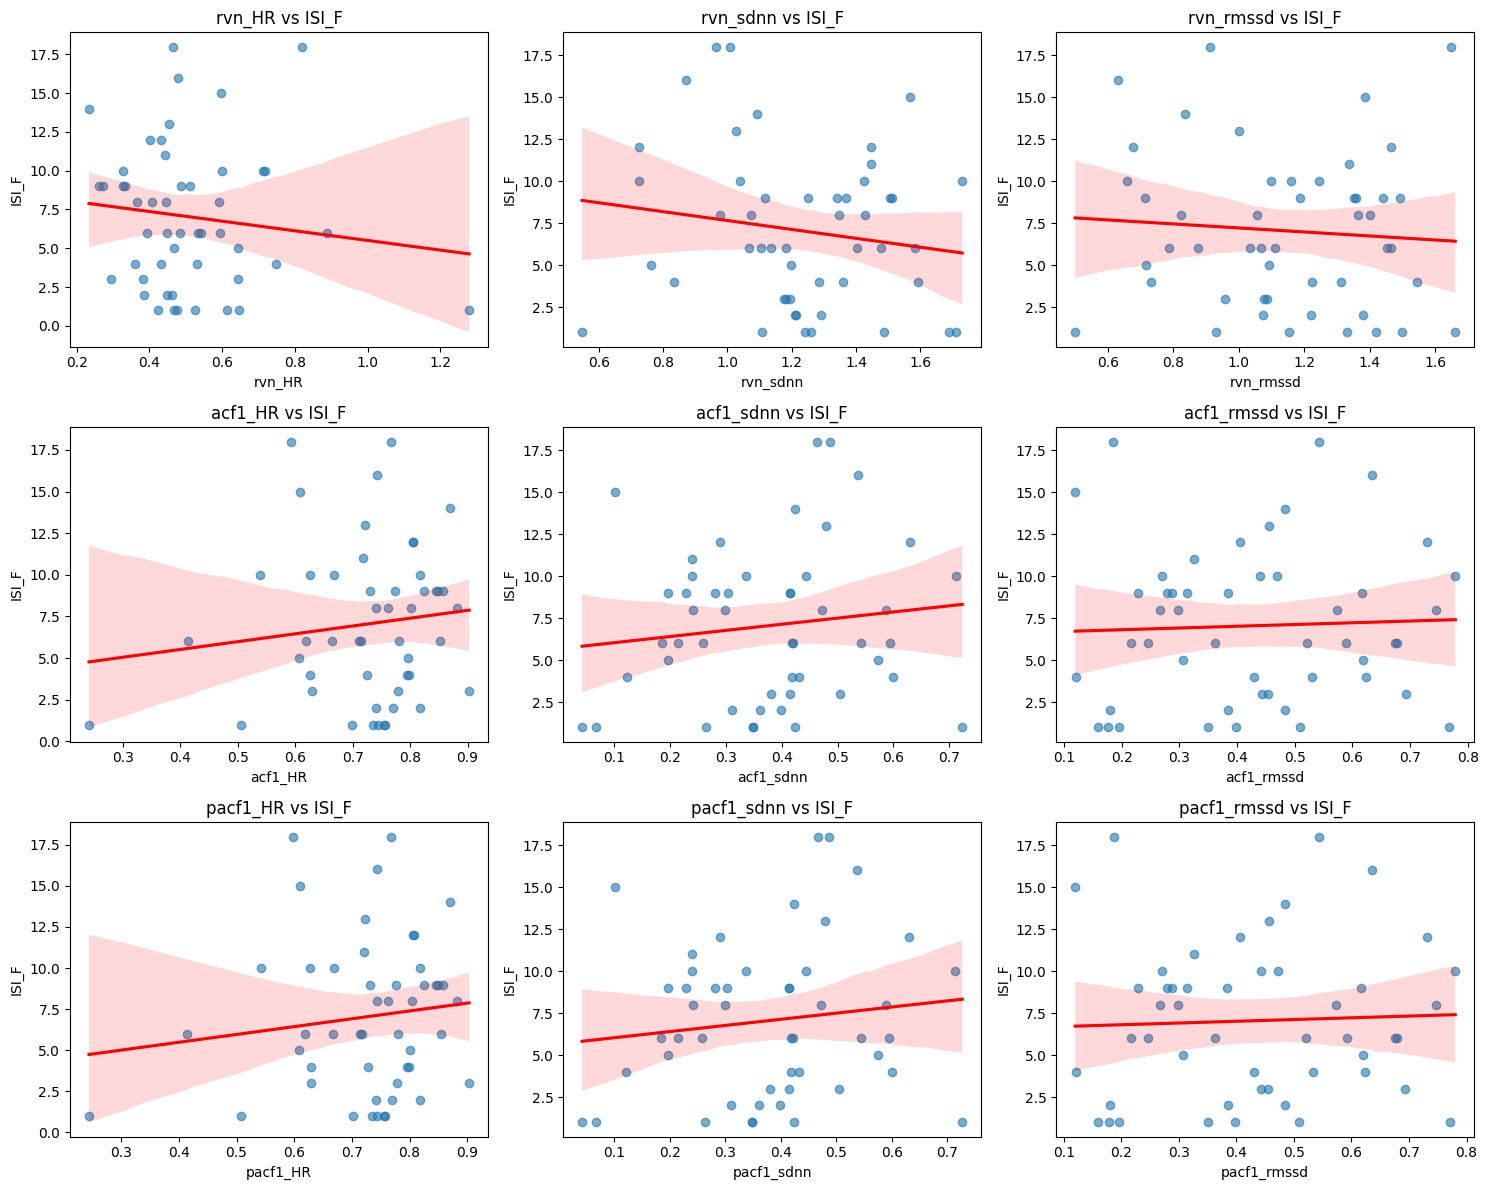

In [68]:
#insomnia
metrics = [
    "rvn_HR", "rvn_sdnn", "rvn_rmssd",
    "acf1_HR", "acf1_sdnn", "acf1_rmssd",
    "pacf1_HR", "pacf1_sdnn", "pacf1_rmssd"
]
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, m in enumerate(metrics):
    sns.regplot(
        data=df_merged,
        x=m,
        y="ISI_F",
        scatter_kws={"alpha":0.6},
        line_kws={"color":"red"},
        ax=axes[i]
    )
    axes[i].set_title(f"{m} vs ISI_F")
plt.tight_layout()
plt.show()

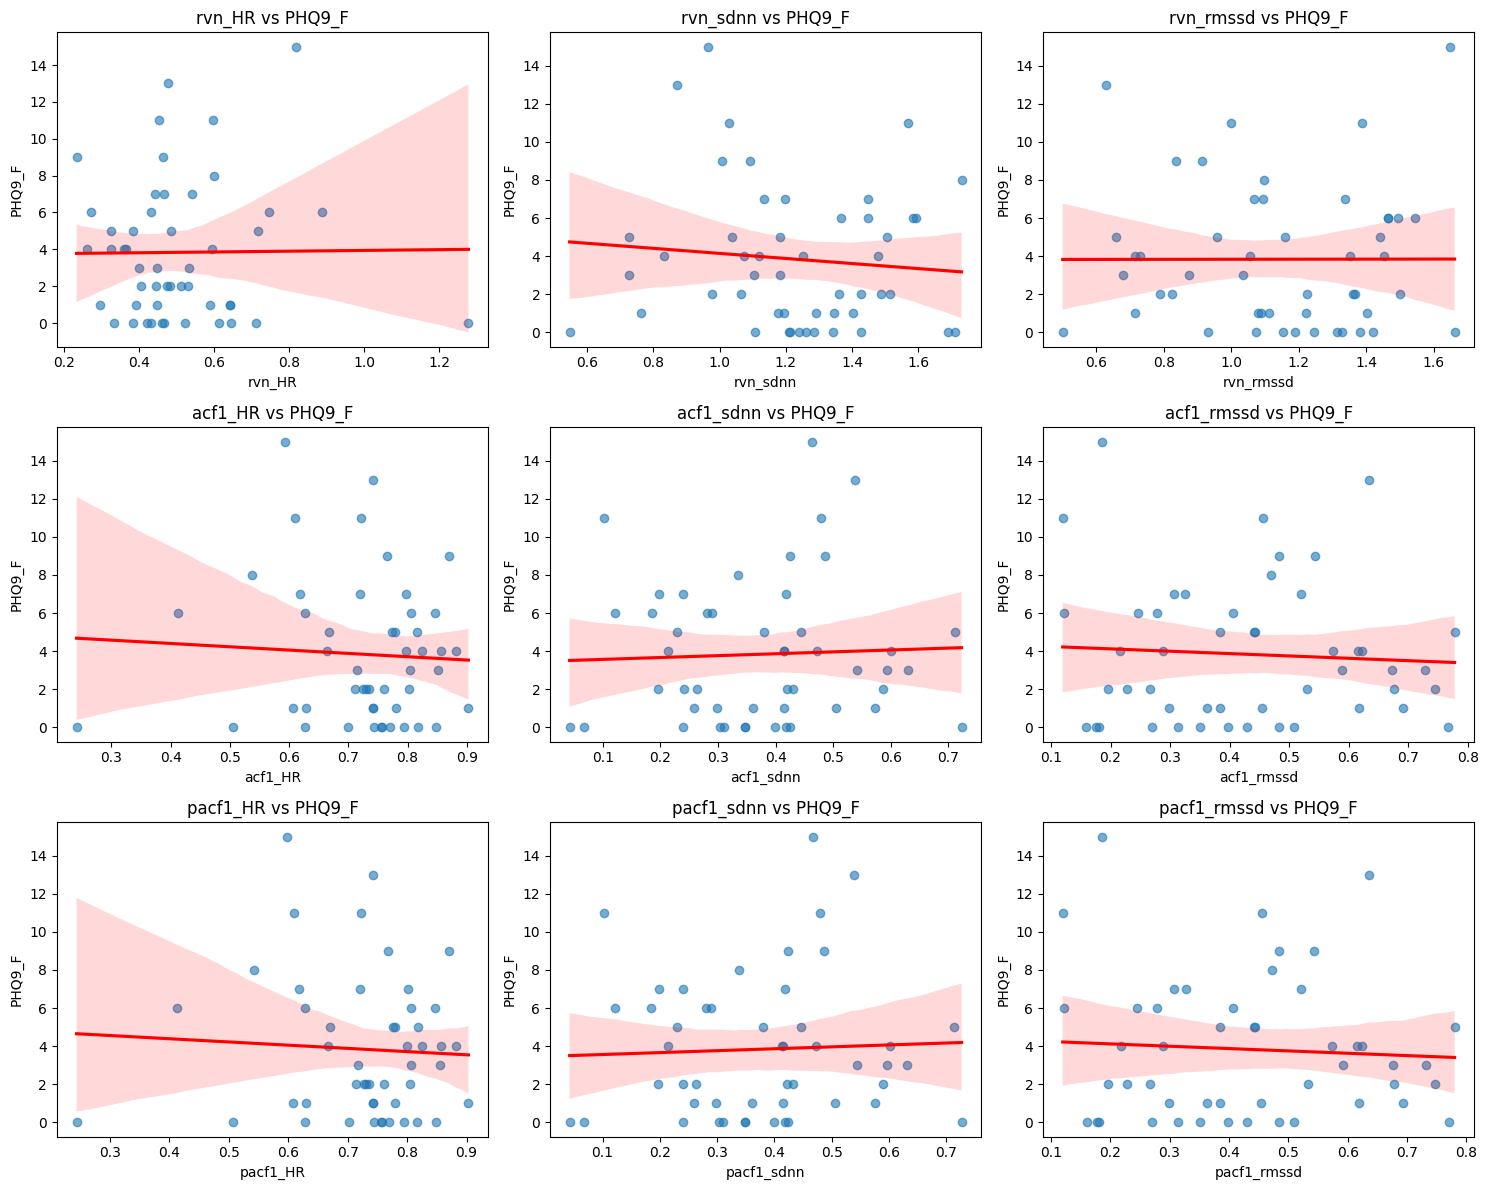

In [69]:
#depression
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, m in enumerate(metrics):
    sns.regplot(
        data=df_merged,
        x=m,
        y="PHQ9_F",
        scatter_kws={"alpha":0.6},
        line_kws={"color":"red"},
        ax=axes[i]
    )
    axes[i].set_title(f"{m} vs PHQ9_F")
plt.tight_layout()
plt.show()

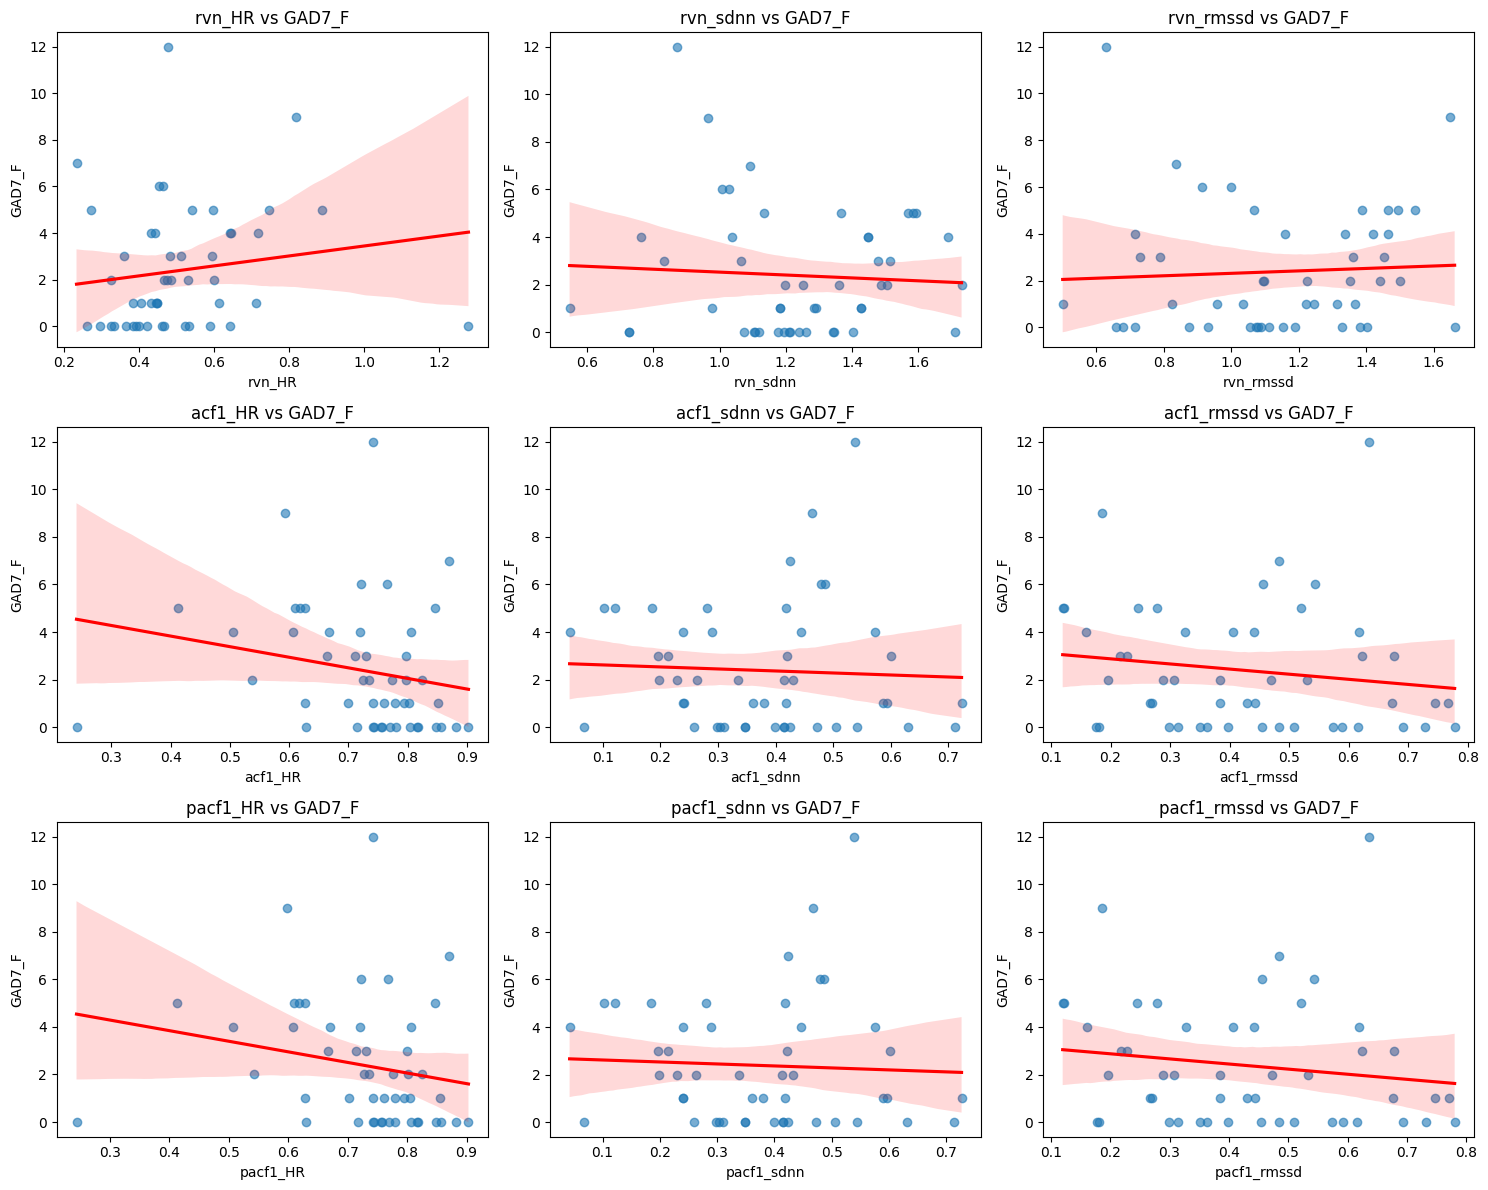

In [70]:
#anxiety
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, m in enumerate(metrics):
    sns.regplot(
        data=df_merged,
        x=m,
        y="GAD7_F",
        scatter_kws={"alpha":0.6},
        line_kws={"color":"red"},
        ax=axes[i]
    )
    axes[i].set_title(f"{m} vs GAD7_F")
plt.tight_layout()
plt.show()